# 0 - IMPORTS

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


import inflection
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OrdinalEncoder, TargetEncoder, StandardScaler

## 0.1 Helper Functions

In [3]:
def vscode_settings():
    plt.style.use('bmh')
    
    plt.rcParams['figure.figsize'] = [25, 12]
    plt.rcParams['font.size'] = 14
    
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option('display.expand_frame_repr', False)
    
    sns.set_palette("Set2")  # ou "Set2", "deep", "colorblind"

vscode_settings()

## 0.2 Load Data

In [4]:
df_raw = pd.read_csv('../data/train.csv')

In [5]:
df_raw.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


# 1 - DATA DESCRIPTION

In [6]:
df1 = df_raw.copy()

## 1.1 Rename/Adjust columns

In [7]:
cols_old = df1.columns

snakecase = lambda x: inflection.underscore(x)
cols_new = list(map(snakecase, cols_old))

df1.columns = cols_new
df1.columns

Index(['id', 'gender', 'age', 'driving_license', 'region_code',
       'previously_insured', 'vehicle_age', 'vehicle_damage', 'annual_premium',
       'policy_sales_channel', 'vintage', 'response'],
      dtype='object')

## 1.2 Data Dimensions

In [8]:
print('Number of Rows: {}'.format(df1.shape[0]))
print('Number of Cols: {}'.format(df1.shape[1]))

Number of Rows: 381109
Number of Cols: 12


## 1.3 Data Types

In [9]:
df1.dtypes

id                        int64
gender                   object
age                       int64
driving_license           int64
region_code             float64
previously_insured        int64
vehicle_age              object
vehicle_damage           object
annual_premium          float64
policy_sales_channel    float64
vintage                   int64
response                  int64
dtype: object

## 1.4 Confirm NA

In [10]:
df1.isna().sum()

id                      0
gender                  0
age                     0
driving_license         0
region_code             0
previously_insured      0
vehicle_age             0
vehicle_damage          0
annual_premium          0
policy_sales_channel    0
vintage                 0
response                0
dtype: int64

## 1.5 Descriptive Statistical

In [11]:
num_attributes = df1.select_dtypes( include=['int64', 'float64'])
cat_attributes = df1.select_dtypes( exclude=['int64', 'float64'])

In [12]:
num_attributes.head()

,id,age,driving_license,region_code,previously_insured,annual_premium,policy_sales_channel,vintage,response
0,1,44,1,28.0,0,40454.0,26.0,217,1
1,2,76,1,3.0,0,33536.0,26.0,183,0
2,3,47,1,28.0,0,38294.0,26.0,27,1
3,4,21,1,11.0,1,28619.0,152.0,203,0
4,5,29,1,41.0,1,27496.0,152.0,39,0


In [13]:
cat_attributes.head()

,gender,vehicle_age,vehicle_damage
0,Male,> 2 Years,Yes
1,Male,1-2 Year,No
2,Male,> 2 Years,Yes
3,Male,< 1 Year,No
4,Female,< 1 Year,No


### 1.5.1 Numerical attributes

In [14]:
# Central Tendency - mean, median
ct1 = pd.DataFrame(num_attributes.apply(np.mean)).T
ct2 = pd.DataFrame(num_attributes.apply(np.median)).T

# Dispersion - std, min, max, range, skew, kurtosis
d1 = pd.DataFrame(num_attributes.apply(np.std)).T
d2 = pd.DataFrame(num_attributes.apply(min)).T
d3 = pd.DataFrame(num_attributes.apply(max)).T
d4 = pd.DataFrame(num_attributes.apply( lambda x: x.max() - x.min())).T
d5 = pd.DataFrame(num_attributes.apply( lambda x: x.skew())).T
d6 = pd.DataFrame(num_attributes.apply( lambda x: x.kurtosis())).T

# concatenate

m = pd.concat([d2,d3,d4,ct1,ct2,d1,d5,d6]).T.reset_index()
m.columns = ['attributes','min','max','range','mean','median','std','skew','kurtosis']

m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,id,1.0,381109.0,381108.0,190555.000000,190555.0,110016.691870,9.443274e-16,-1.200000
1,age,20.0,85.0,65.0,38.822584,36.0,15.511591,6.725390e-01,-0.565655
2,driving_license,0.0,1.0,1.0,0.997869,1.0,0.046109,-2.159518e+01,464.354302
3,region_code,0.0,52.0,52.0,26.388807,28.0,13.229871,-1.152664e-01,-0.867857
4,previously_insured,0.0,1.0,1.0,0.458210,0.0,0.498251,1.677471e-01,-1.971871
5,annual_premium,2630.0,540165.0,537535.0,30564.389581,31669.0,17213.132474,1.766087e+00,34.004569
6,policy_sales_channel,1.0,163.0,162.0,112.034295,133.0,54.203924,-9.000081e-01,-0.970810
7,vintage,10.0,299.0,289.0,154.347397,154.0,83.671194,3.029517e-03,-1.200688
8,response,0.0,1.0,1.0,0.122563,0.0,0.327935,2.301906e+00,3.298788


### 1.5.2 Categorical attributes

In [15]:
cat_attributes.apply( lambda x: x.unique().shape[0])

gender            2
vehicle_age       3
vehicle_damage    2
dtype: int64

# 2 - FEATURE ENGINEERING

In [16]:
df2 = df1.copy()

In [17]:
df2.head()

,id,gender,age,driving_license,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [18]:
# Feature engineering - vehicle_age
df2['vehicle_age'] = df2['vehicle_age'].map({
    '< 1 Year': 'before_1_year',
    '1-2 Year': 'between_1_2_years',
    '> 2 Years': 'over_2_years'
})

In [19]:
bins = list(range(20, df2['age'].max() + 6, 5))
labels = [f'{bins[i]}-{bins[i+1]-1}' for i in range(len(bins)-1)]

df2['age_group'] = pd.cut(df2['age'], bins=bins, labels=labels, right=False)

# 3 - VARIABLE FILTERING

In [20]:
df3 = df2.copy()

# 4 - EDA

In [21]:
df4 = df2.copy()

## 4.1 Univariate Analysis

### 4.1.1 Numerical

In [22]:
num_attributes = num_attributes.drop(['id', 'policy_sales_channel'], axis=1)

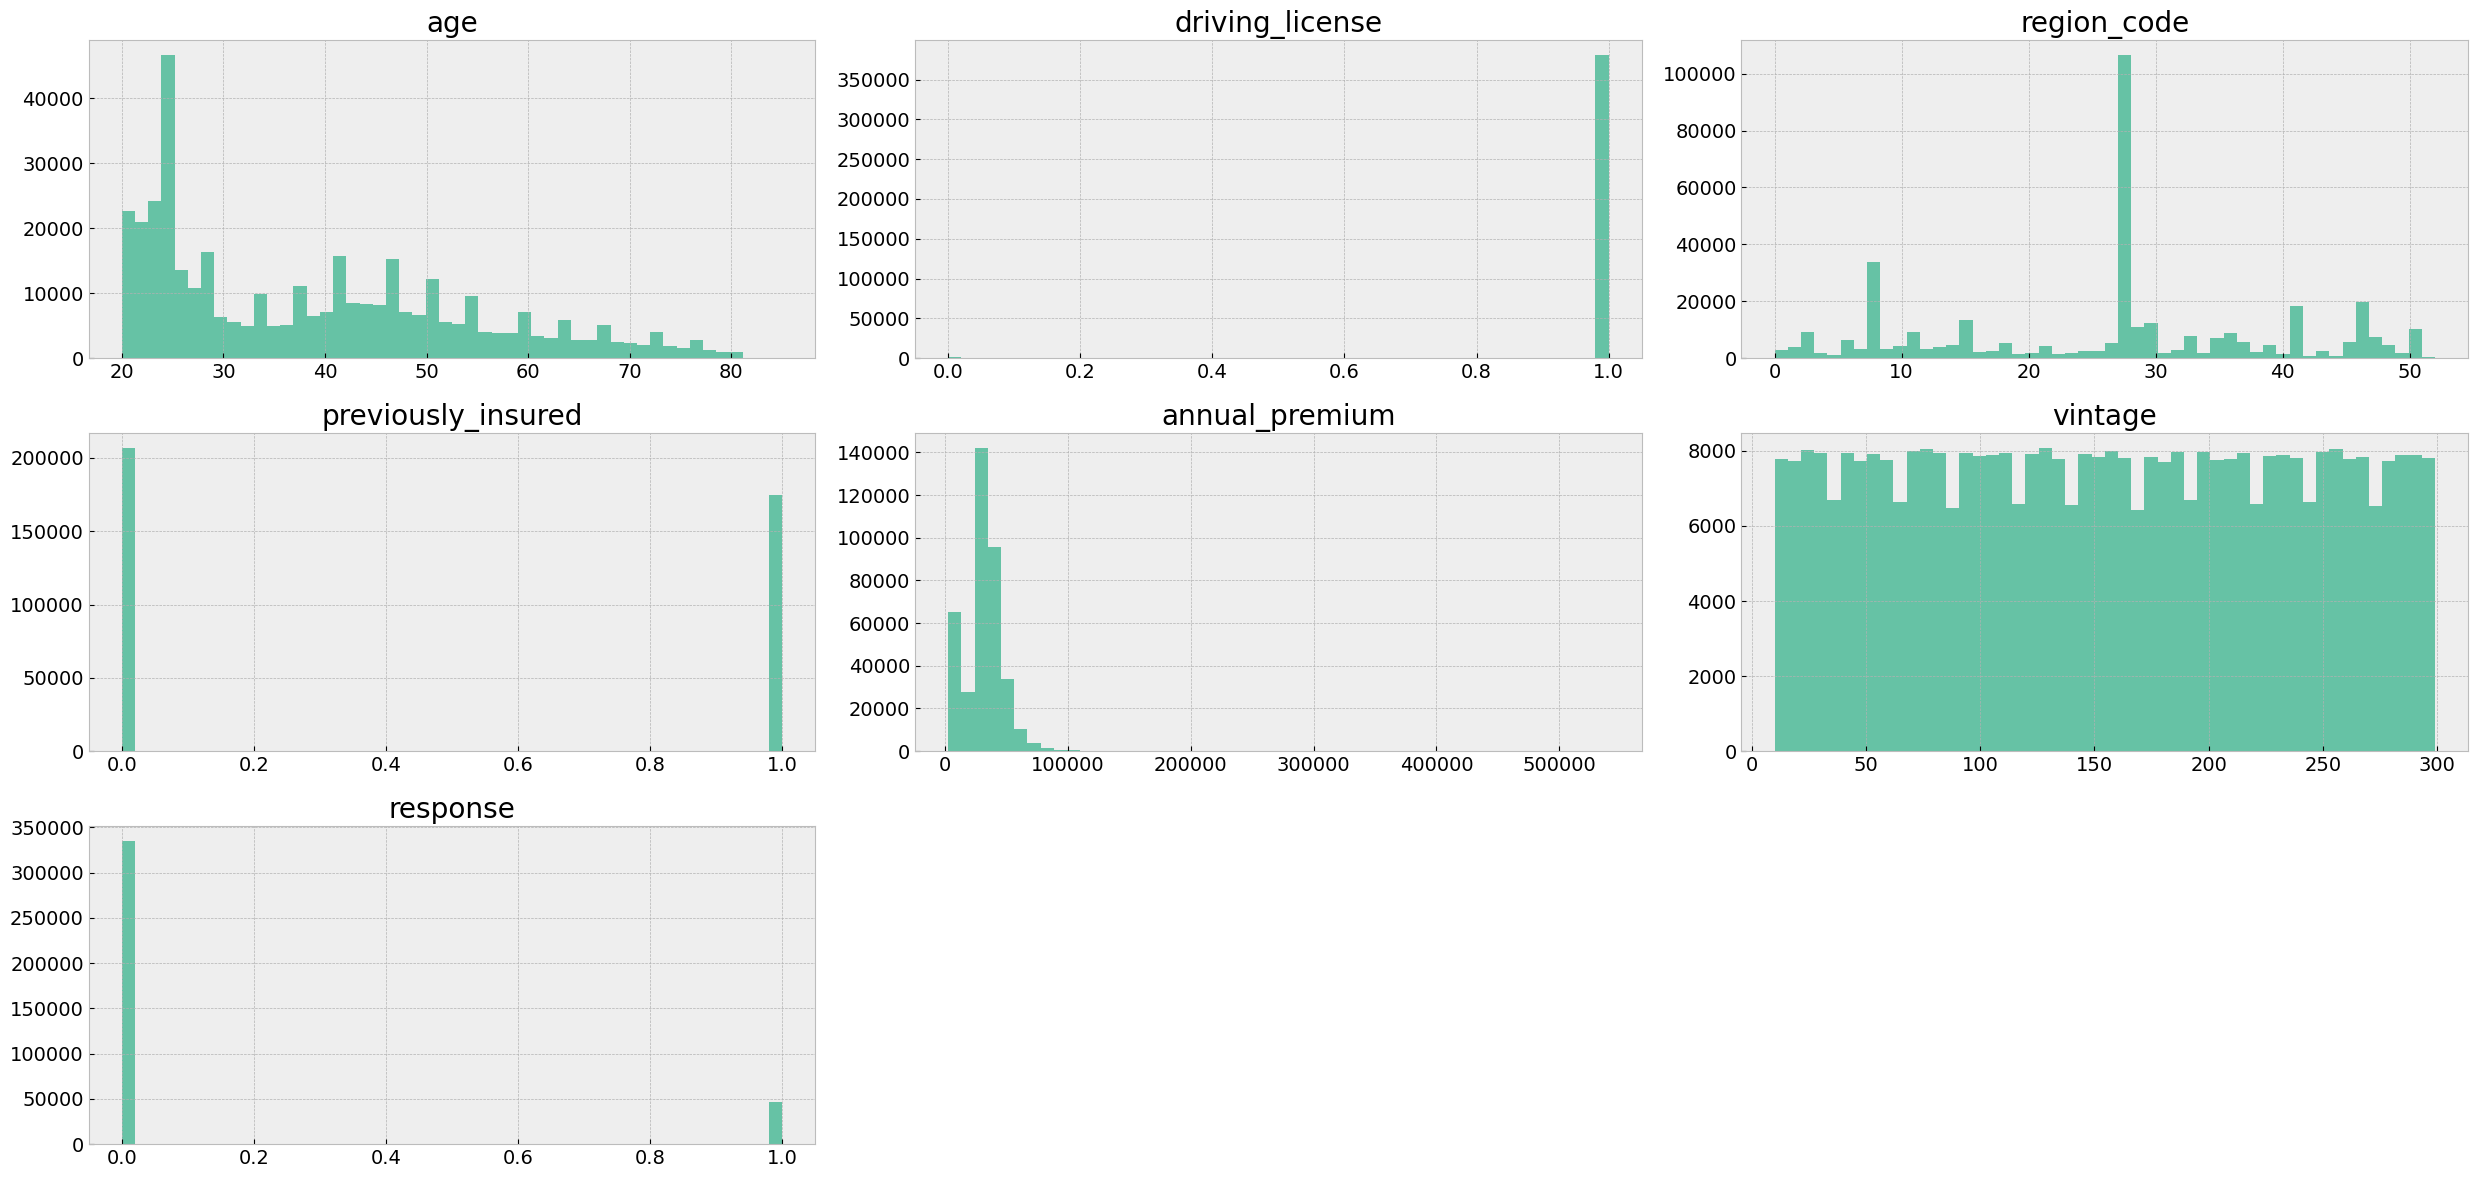

In [23]:
num_attributes.hist(bins=50)
plt.tight_layout()
plt.show()

### 4.1.2 Categorical

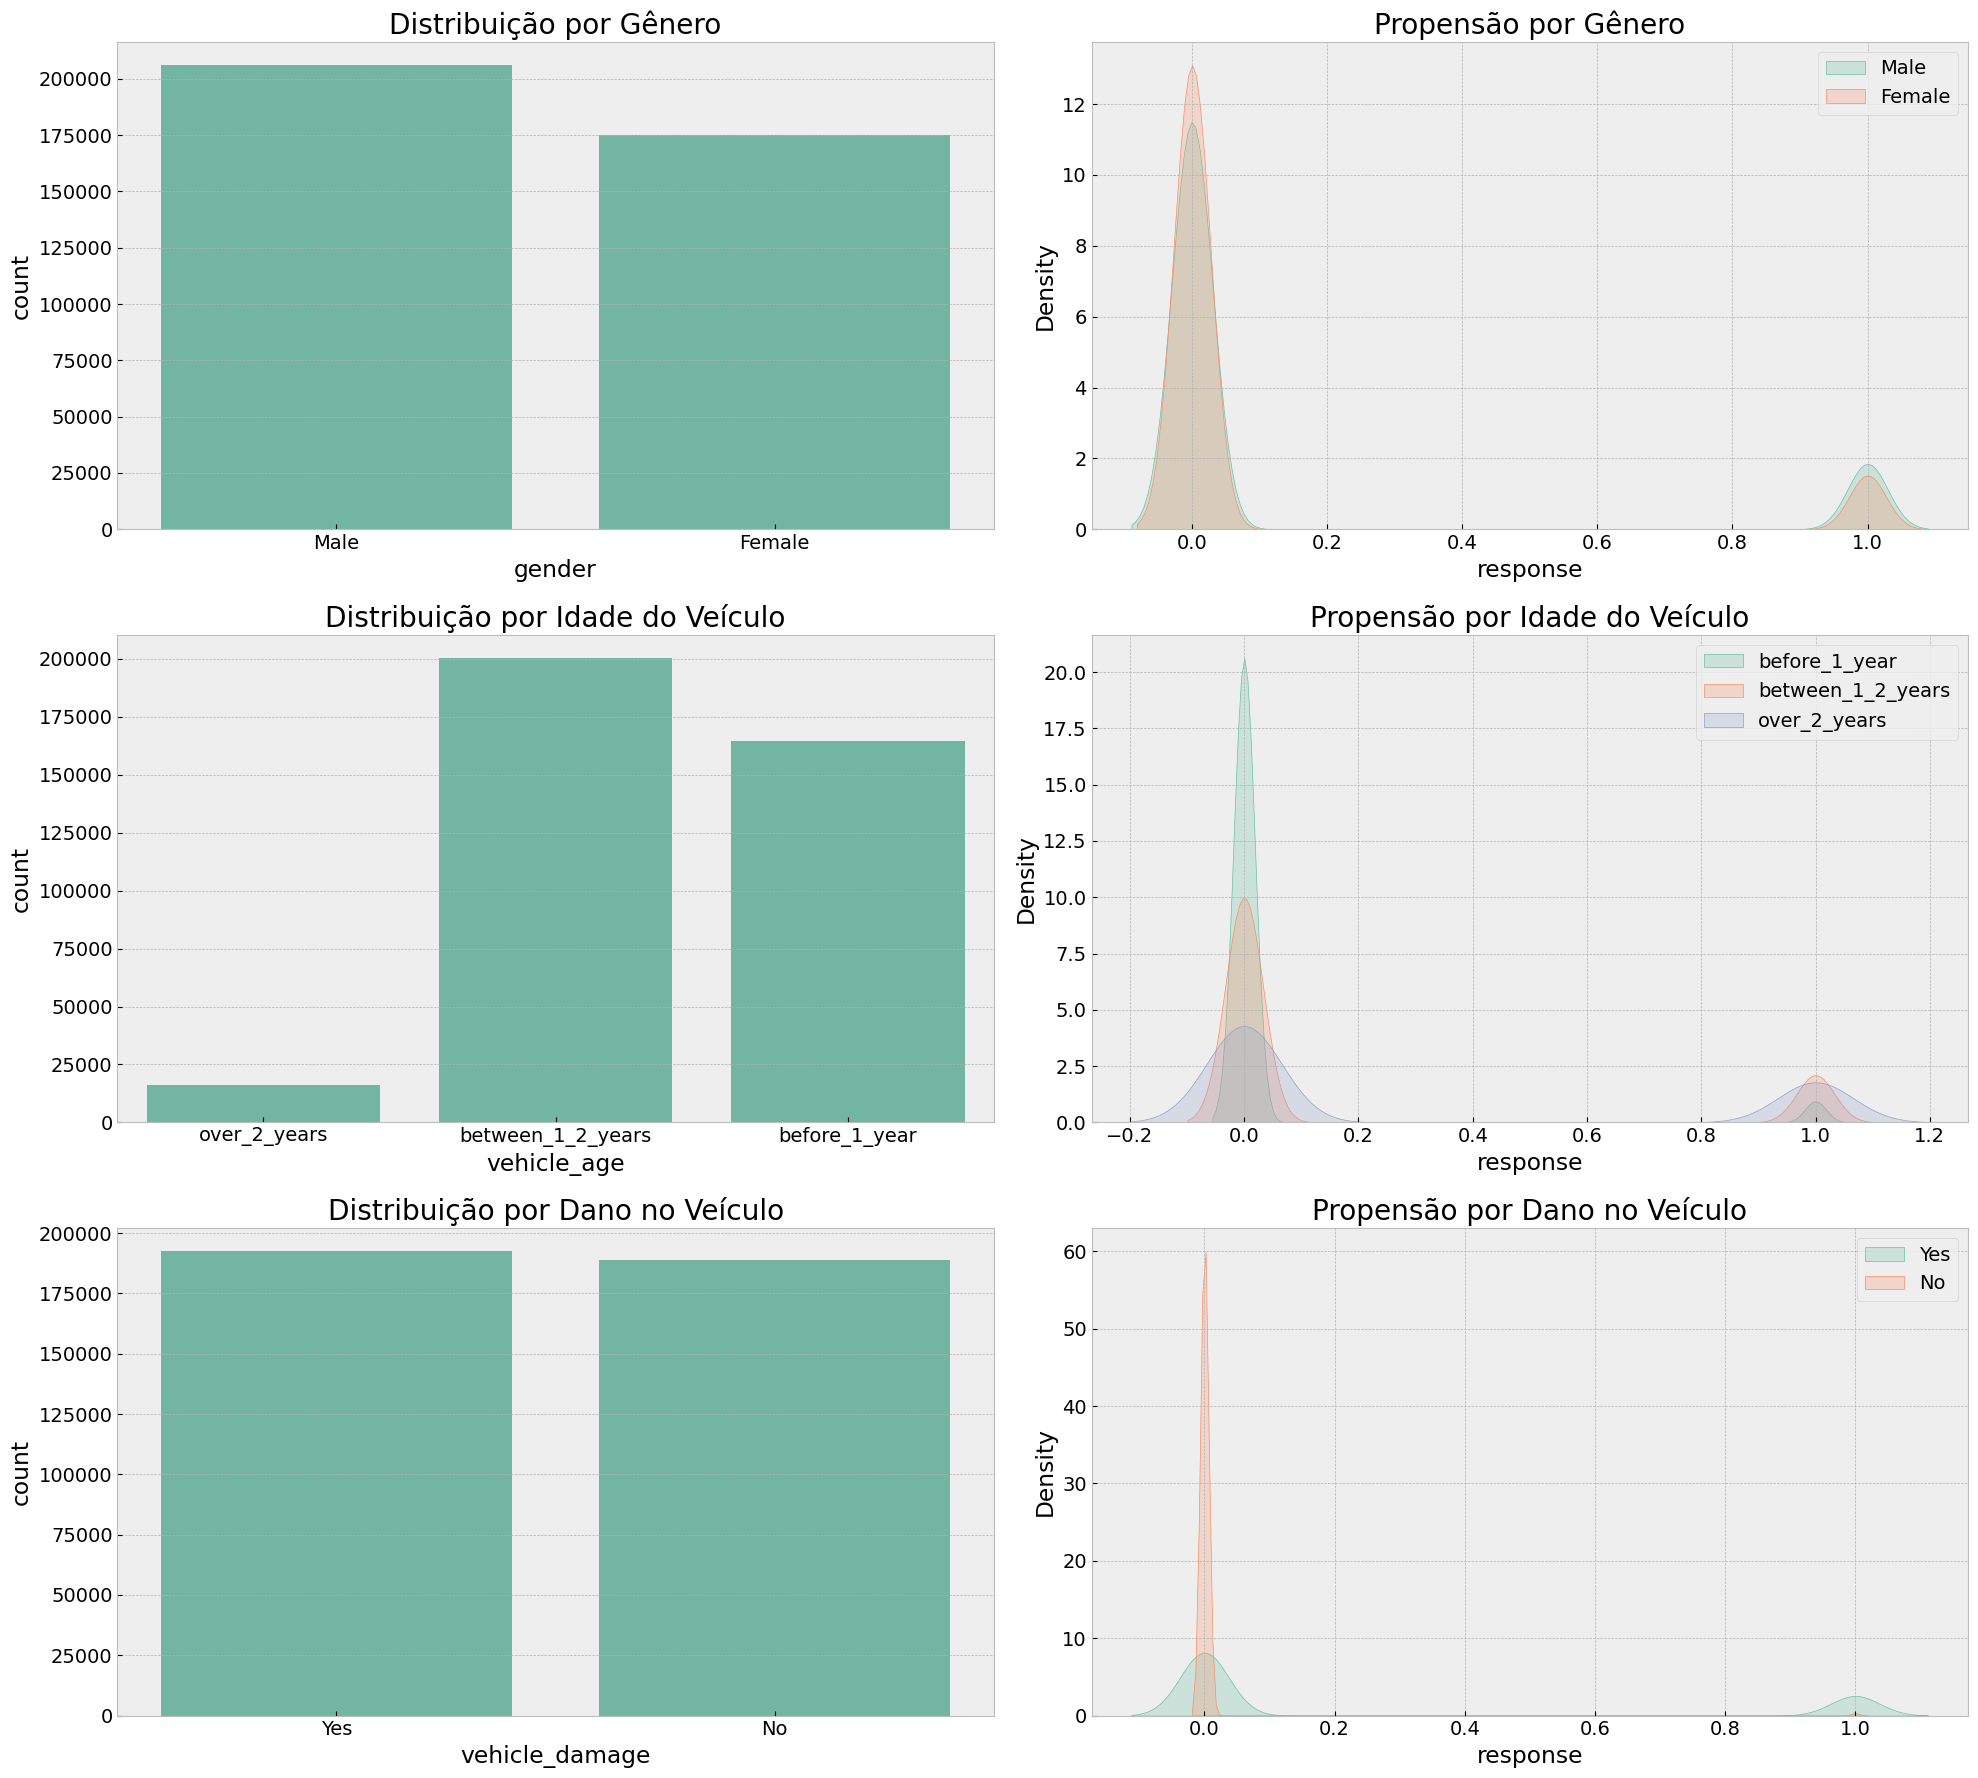

In [24]:
fig, axes = plt.subplots(3, 2, figsize=(20, 18))

# gender - countplot
sns.countplot(x='gender', data=df4, ax=axes[0,0])
axes[0,0].set_title('Distribuição por Gênero')

# gender - KDE
sns.kdeplot(df4[df4['gender'] == 'Male']['response'], label='Male', fill=True, ax=axes[0,1])
sns.kdeplot(df4[df4['gender'] == 'Female']['response'], label='Female', fill=True, ax=axes[0,1])
axes[0,1].set_title('Propensão por Gênero')
axes[0,1].legend()

# vehicle_age - countplot
sns.countplot(x='vehicle_age', data=df4, ax=axes[1,0])
axes[1,0].set_title('Distribuição por Idade do Veículo')

# vehicle_age - KDE
sns.kdeplot(df4[df4['vehicle_age'] == 'before_1_year']['response'], label='before_1_year', fill=True, ax=axes[1,1])
sns.kdeplot(df4[df4['vehicle_age'] == 'between_1_2_years']['response'], label='between_1_2_years', fill=True, ax=axes[1,1])
sns.kdeplot(df4[df4['vehicle_age'] == 'over_2_years']['response'], label='over_2_years', fill=True, ax=axes[1,1])
axes[1,1].set_title('Propensão por Idade do Veículo')
axes[1,1].legend()

# vehicle_damage - countplot
sns.countplot(x='vehicle_damage', data=df4, ax=axes[2,0])
axes[2,0].set_title('Distribuição por Dano no Veículo')

# vehicle_damage - KDE
sns.kdeplot(df4[df4['vehicle_damage'] == 'Yes']['response'], label='Yes', fill=True, ax=axes[2,1])
sns.kdeplot(df4[df4['vehicle_damage'] == 'No']['response'], label='No', fill=True, ax=axes[2,1])
axes[2,1].set_title('Propensão por Dano no Veículo')
axes[2,1].legend()

plt.tight_layout()
plt.show()

## 4.2 Bivariate Analysis

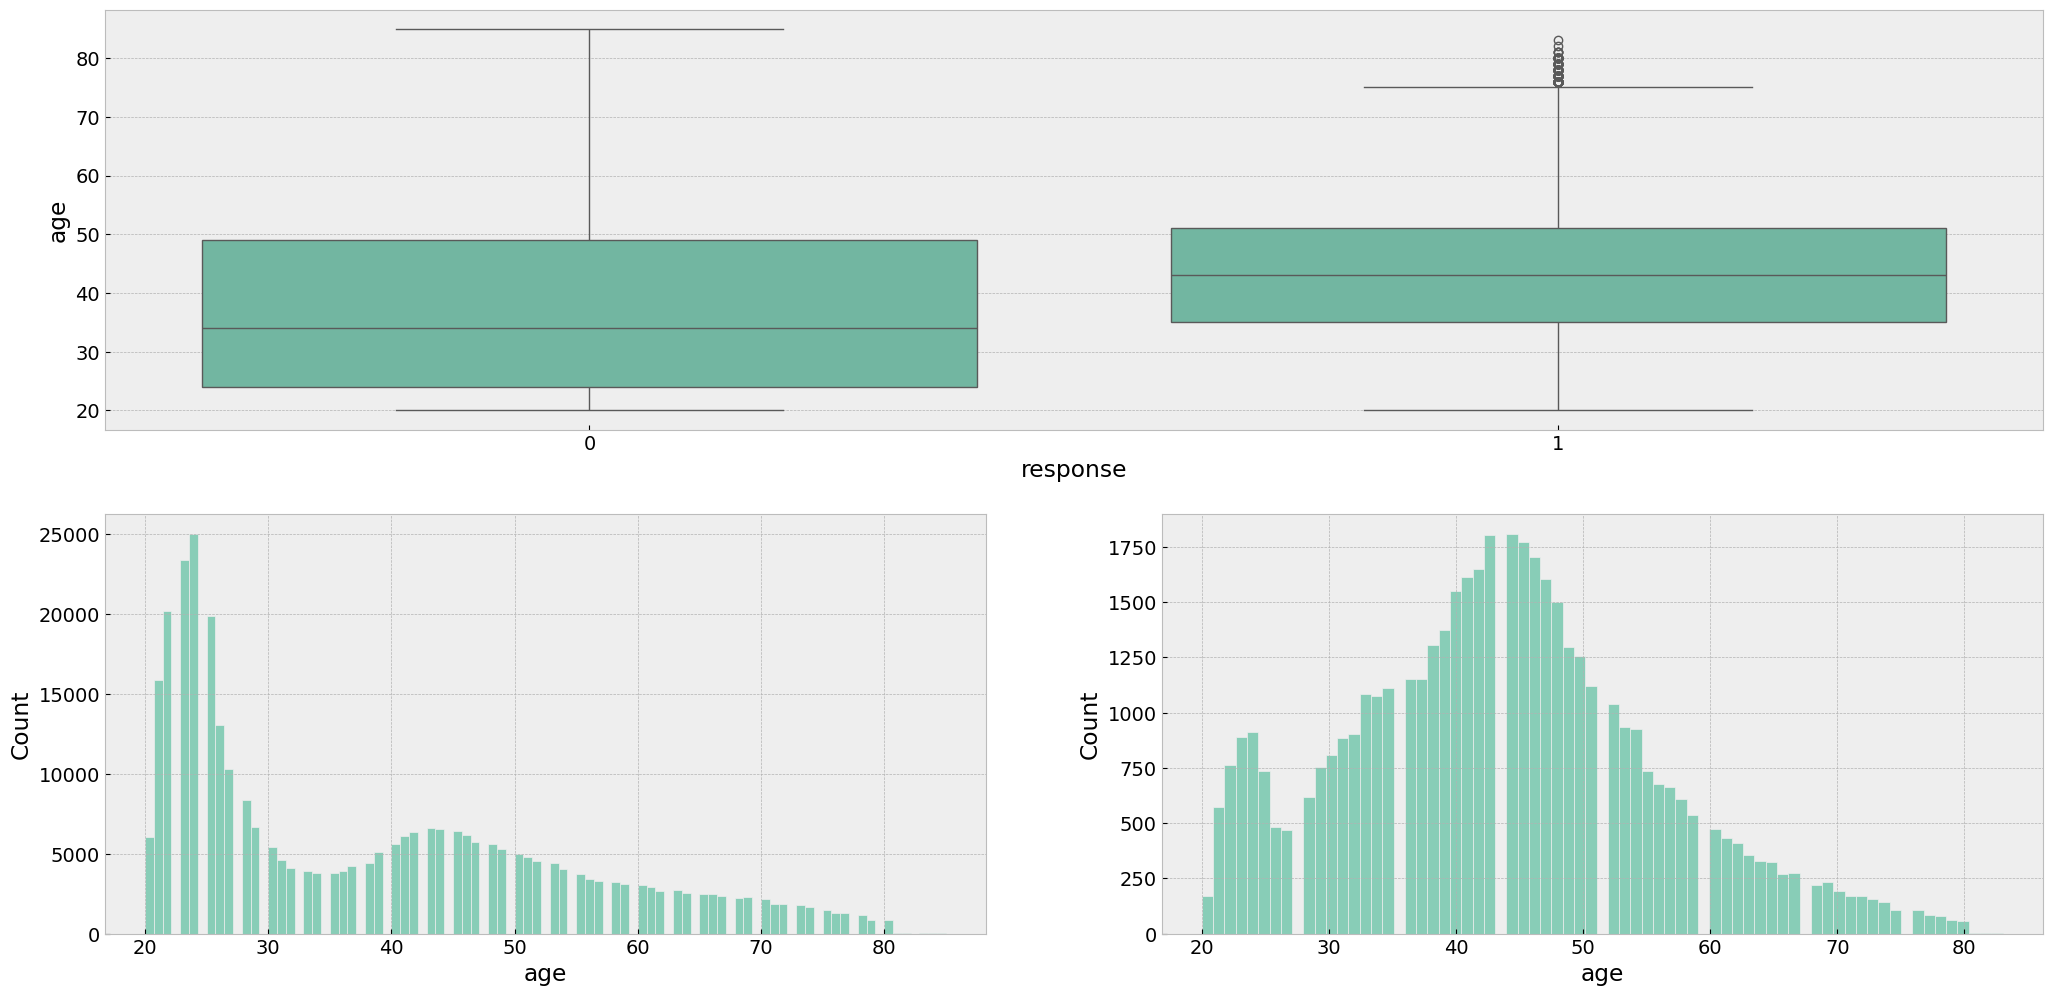

In [25]:
# age
plt.subplot(2,1,1)
sns.boxplot(x='response', y='age', data=df4)

plt.subplot(2,2,3)
sns.histplot(df4.loc[df4['response'] == 0, 'age'])

plt.subplot(2,2,4)
sns.histplot(df4.loc[df4['response'] == 1, 'age']);

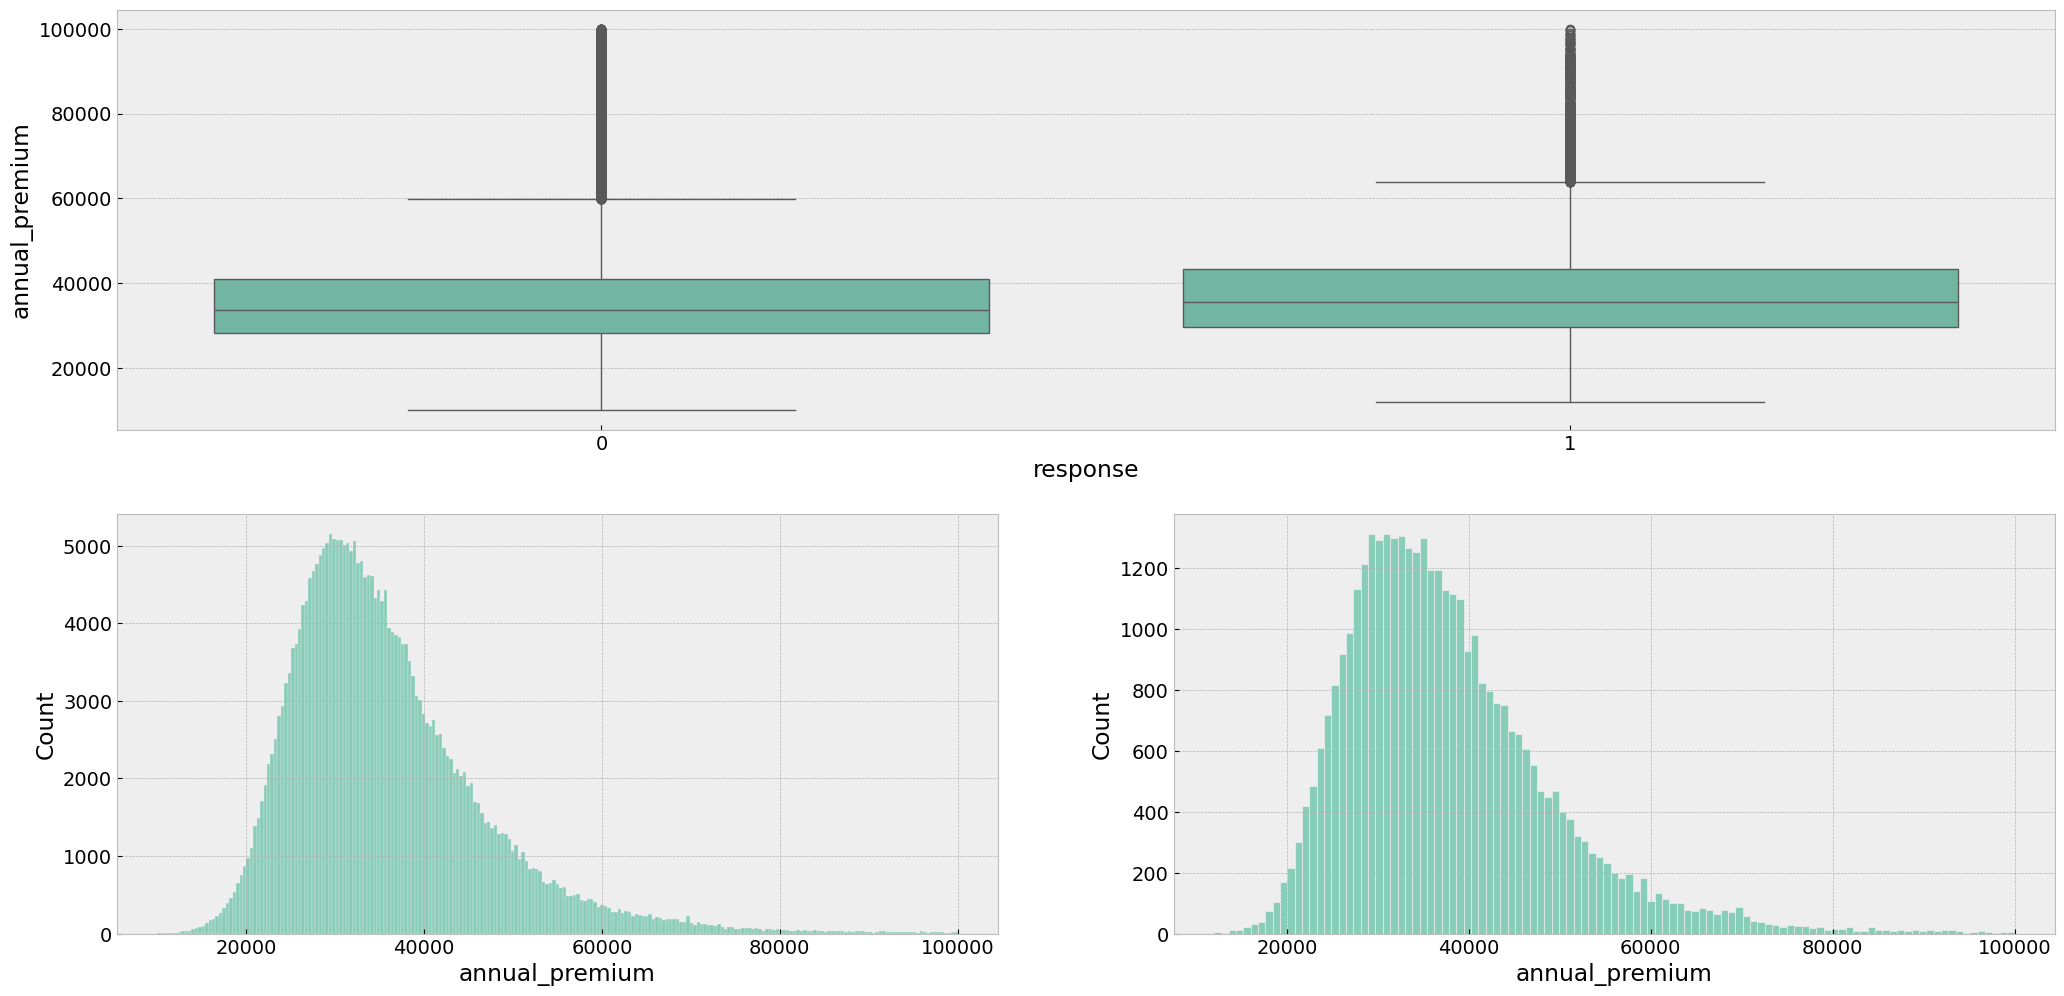

In [26]:
# annual_premium
aux = df4[(df4['annual_premium'] > 10000) & (df4['annual_premium'] < 100000) ]

plt.subplot(2,1,1)
sns.boxplot(x='response', y='annual_premium', data=aux)

plt.subplot(2,2,3)
sns.histplot(aux.loc[aux['response'] == 0, 'annual_premium'])

plt.subplot(2,2,4)
sns.histplot(aux.loc[aux['response'] == 1, 'annual_premium']);

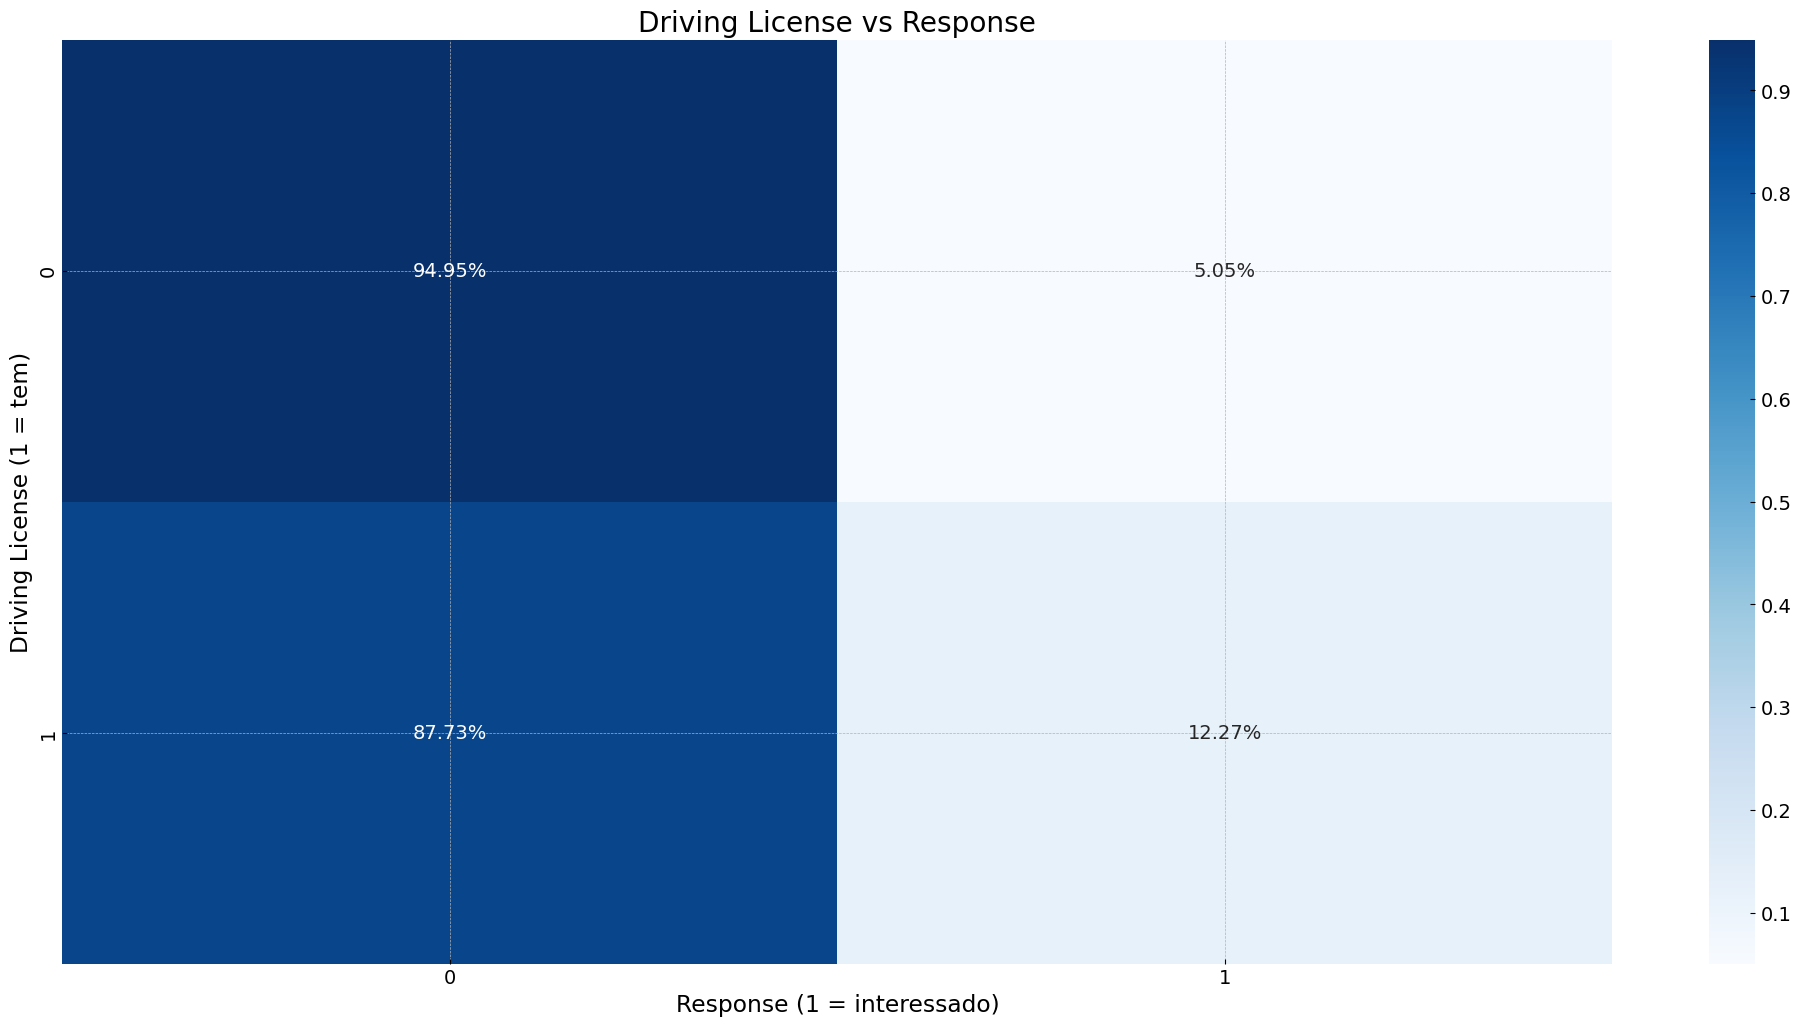

In [27]:
# driving_license

# Tabela cruzada
crosstab_prop = pd.crosstab(
    df4['driving_license'], 
    df4['response'], 
    normalize='index'
)

# Heatmap 
sns.heatmap(
    crosstab_prop,
    annot=True,
    fmt='.2%',
    cmap='Blues',
    cbar=True
)

plt.title('Driving License vs Response')
plt.xlabel('Response (1 = interessado)')
plt.ylabel('Driving License (1 = tem)')
plt.show()

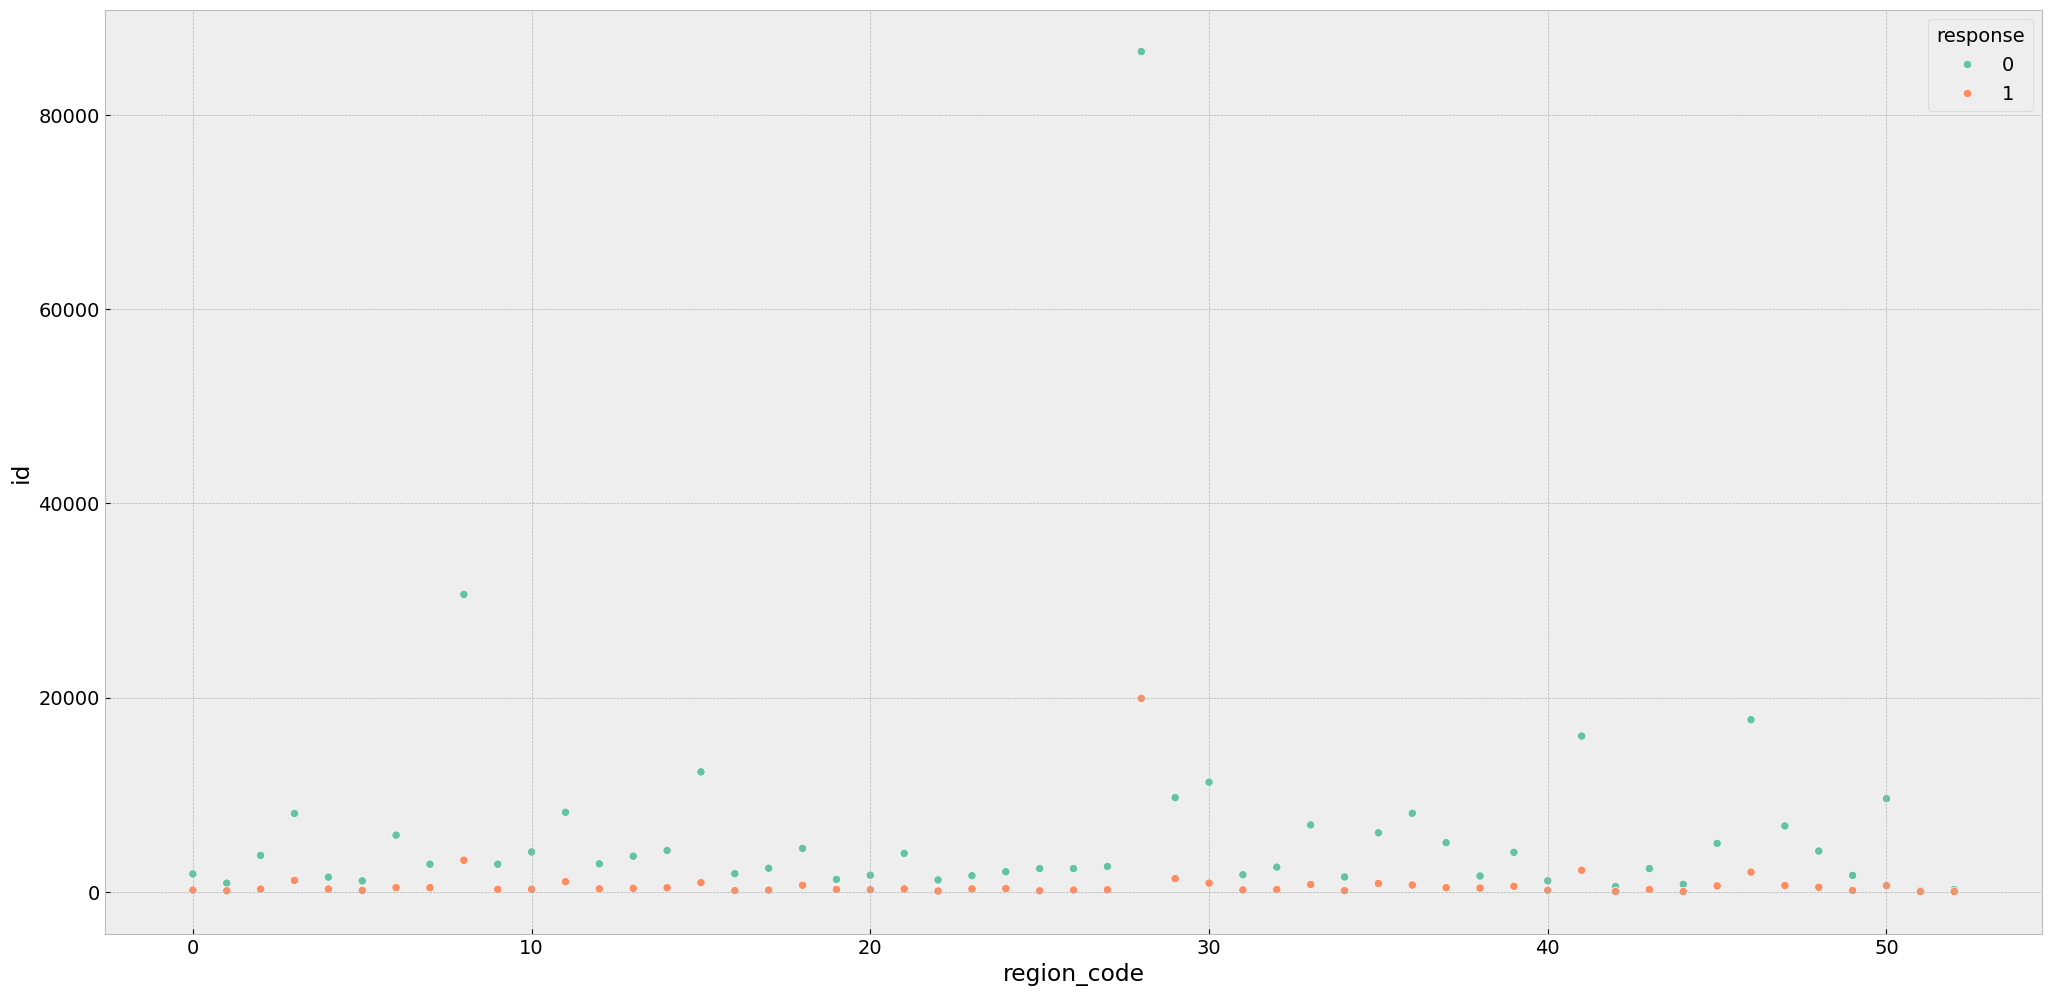

In [28]:
# region_code

ax = df4[['id', 'region_code', 'response']].groupby(['region_code', 'response']).count().reset_index()

sns.scatterplot(x='region_code', y='id', hue='response', data=ax);

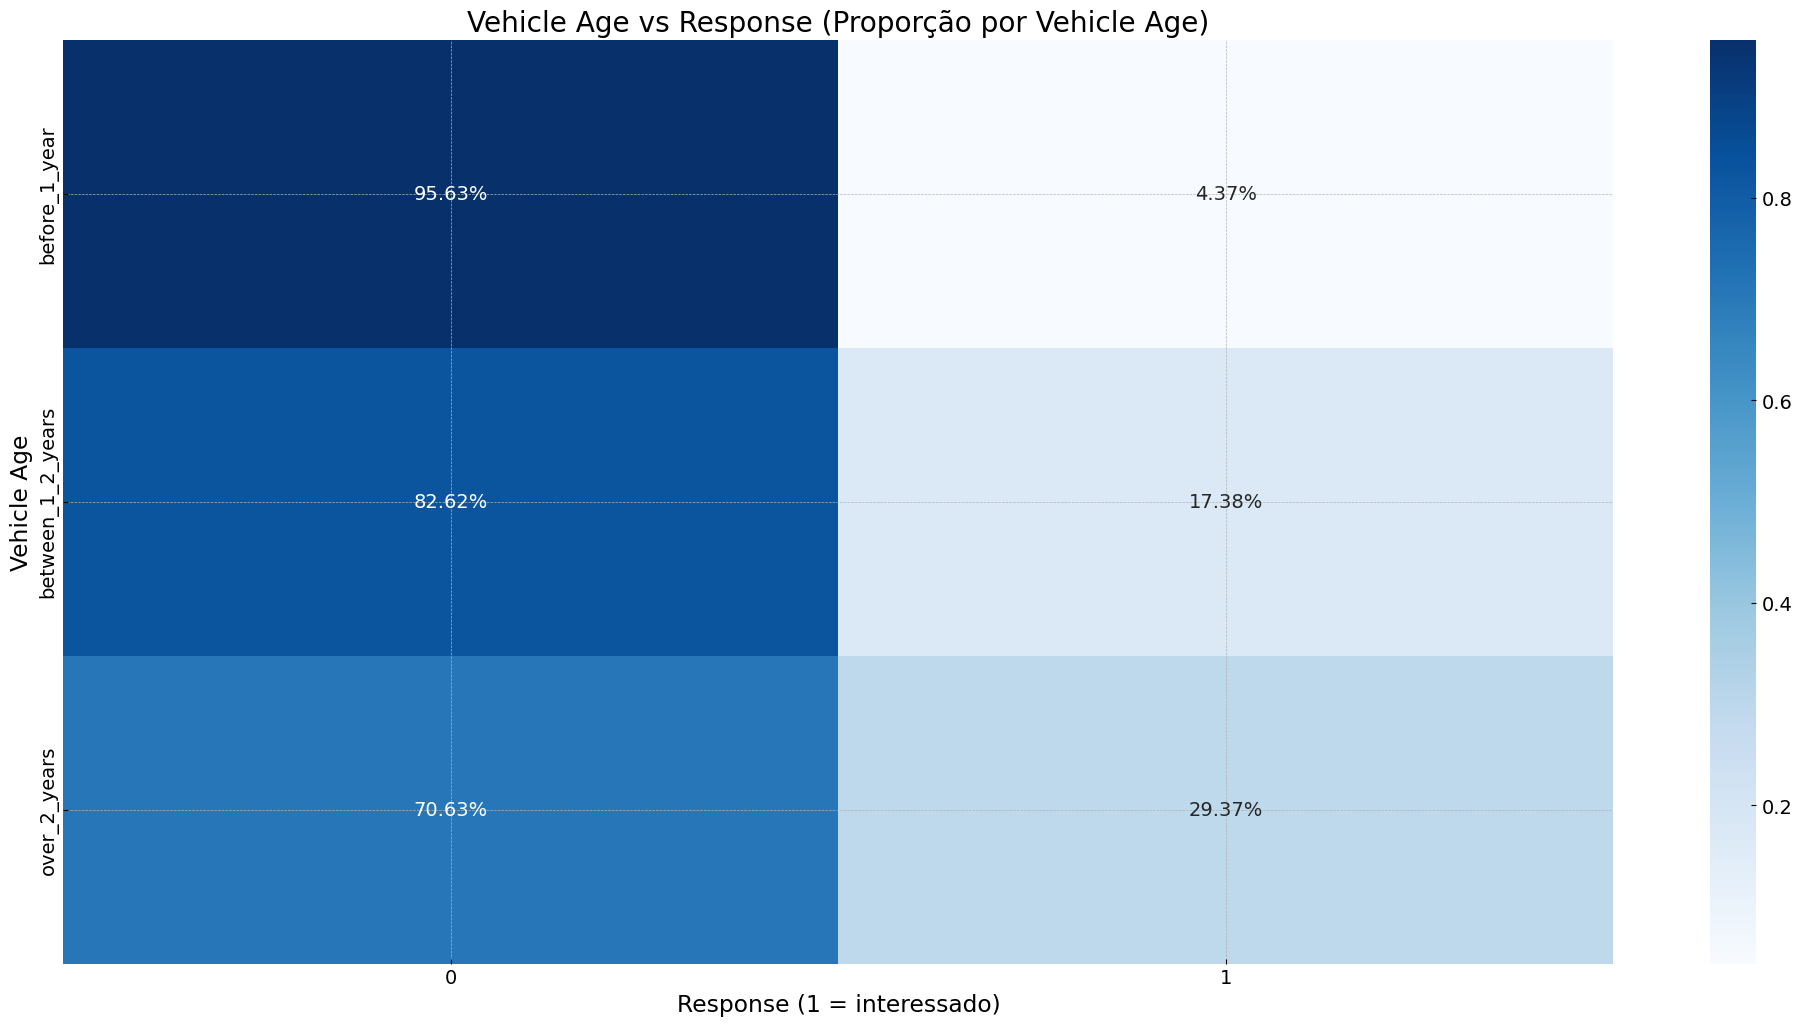

In [29]:
# vehicle_age


# Crosstab
crosstab_prop = pd.crosstab(
    df4['vehicle_age'],
    df4['response'],
    normalize='index'
)


sns.heatmap(
    crosstab_prop,
    annot=True,
    fmt='.2%',
    cmap='Blues',
    cbar=True
)

plt.title('Vehicle Age vs Response (Proporção por Vehicle Age)')
plt.xlabel('Response (1 = interessado)')
plt.ylabel('Vehicle Age')
plt.show()


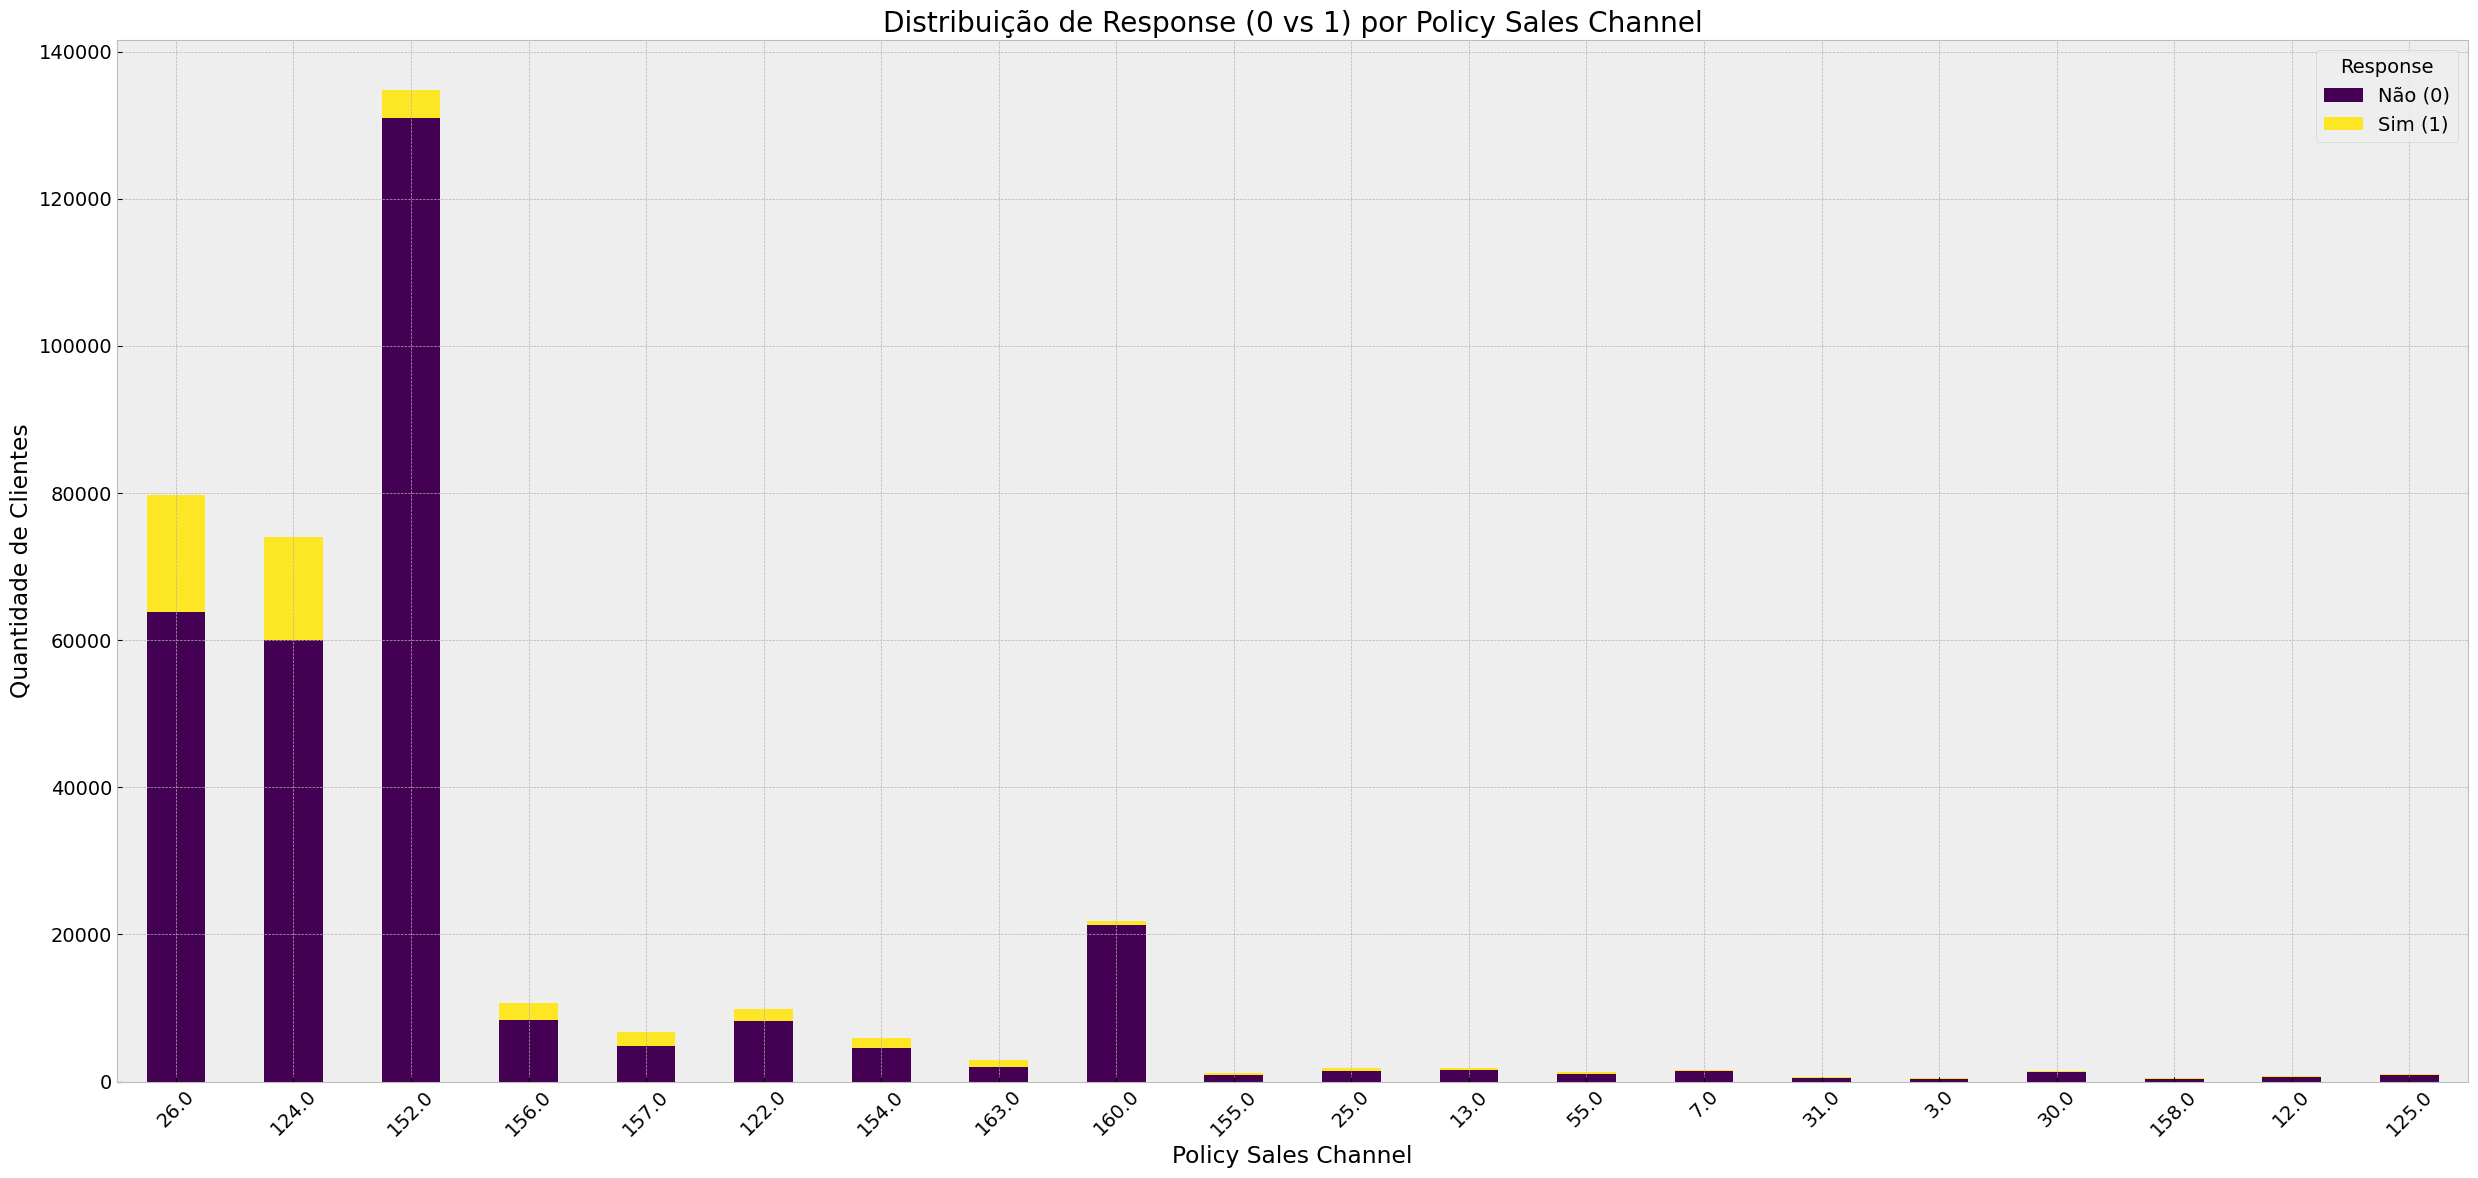

In [30]:
# policy_sales_channel

channel_response = pd.crosstab(
    df4['policy_sales_channel'],
    df4['response']
)

# canais mais relevantes
channel_response = channel_response.sort_values(1, ascending=False).head(20)

channel_response.plot(
    kind='bar',      
    stacked=True,
    ax=plt.gca(),
    colormap='viridis'
)

plt.xlabel('Policy Sales Channel')
plt.ylabel('Quantidade de Clientes')
plt.title('Distribuição de Response (0 vs 1) por Policy Sales Channel')

plt.legend(
    title='Response',
    labels=['Não (0)', 'Sim (1)']
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



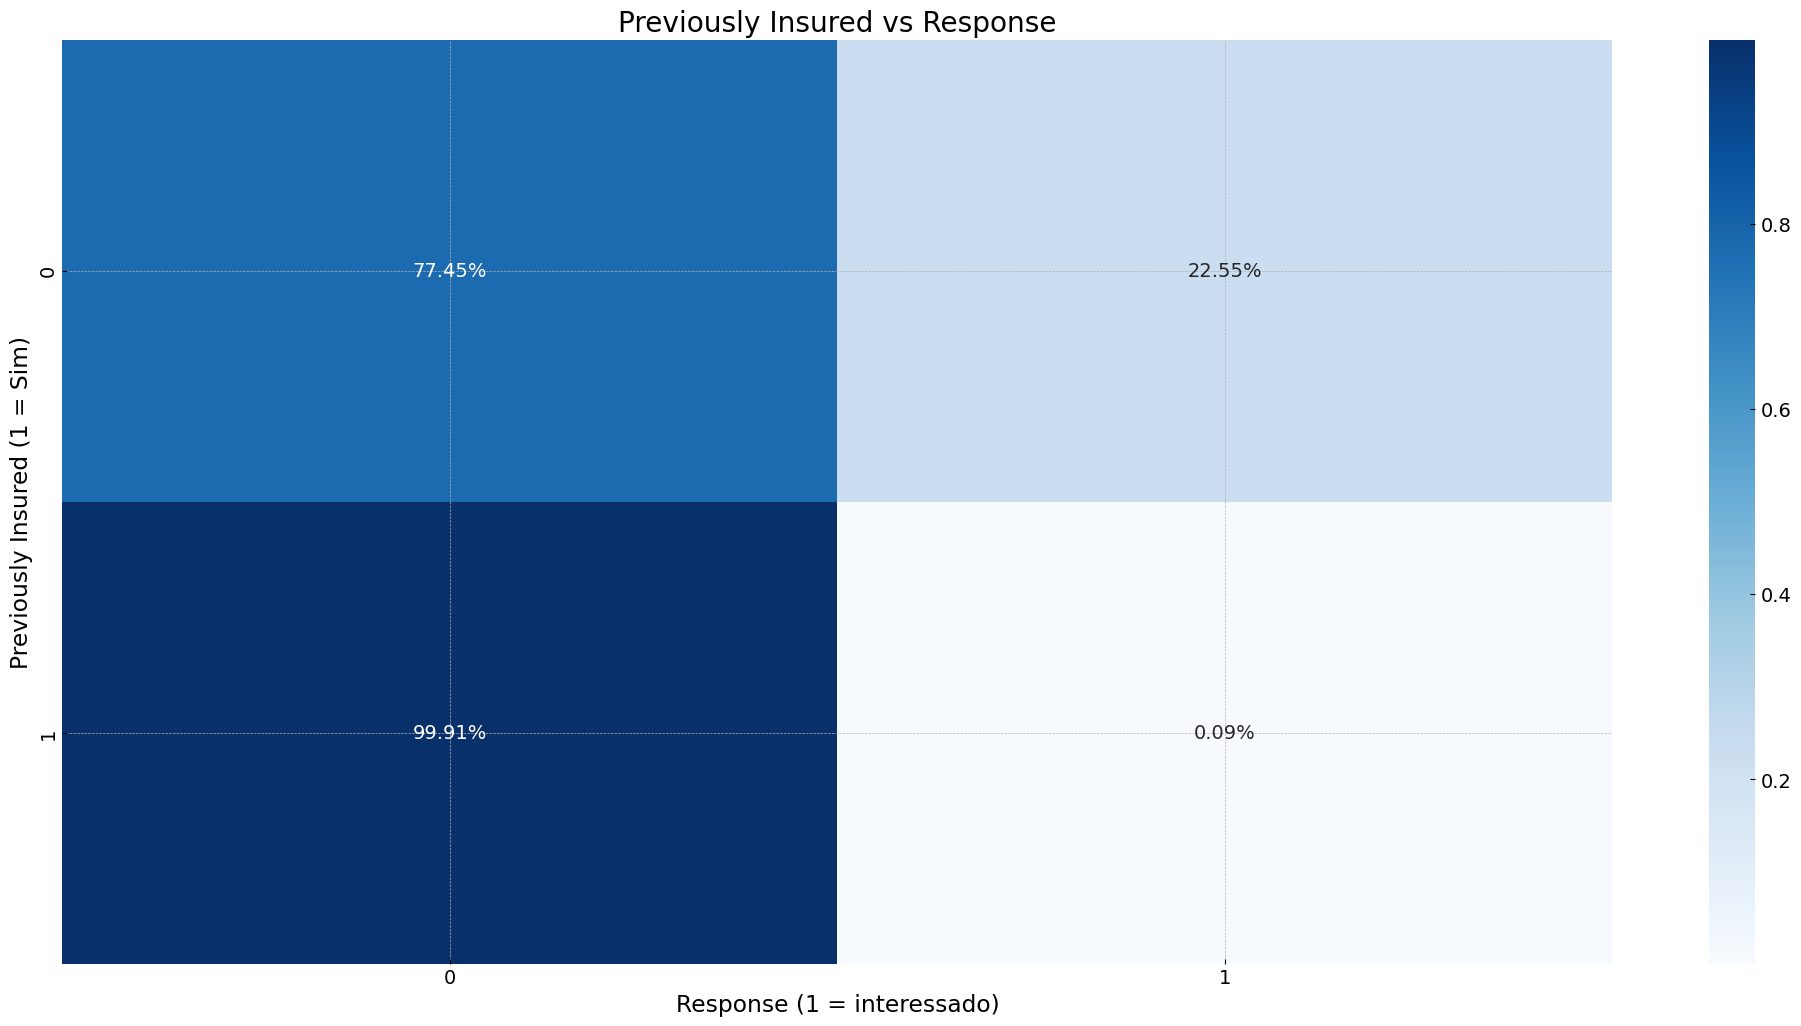

In [31]:
# previously_insured

# Tabela cruzada
crosstab_prop = pd.crosstab(
    df4['previously_insured'], 
    df4['response'], 
    normalize='index'
)

# Heatmap 
sns.heatmap(
    crosstab_prop,
    annot=True,
    fmt='.2%',
    cmap='Blues',
    cbar=True
)

plt.title('Previously Insured vs Response')
plt.xlabel('Response (1 = interessado)')
plt.ylabel('Previously Insured (1 = Sim)')
plt.show()

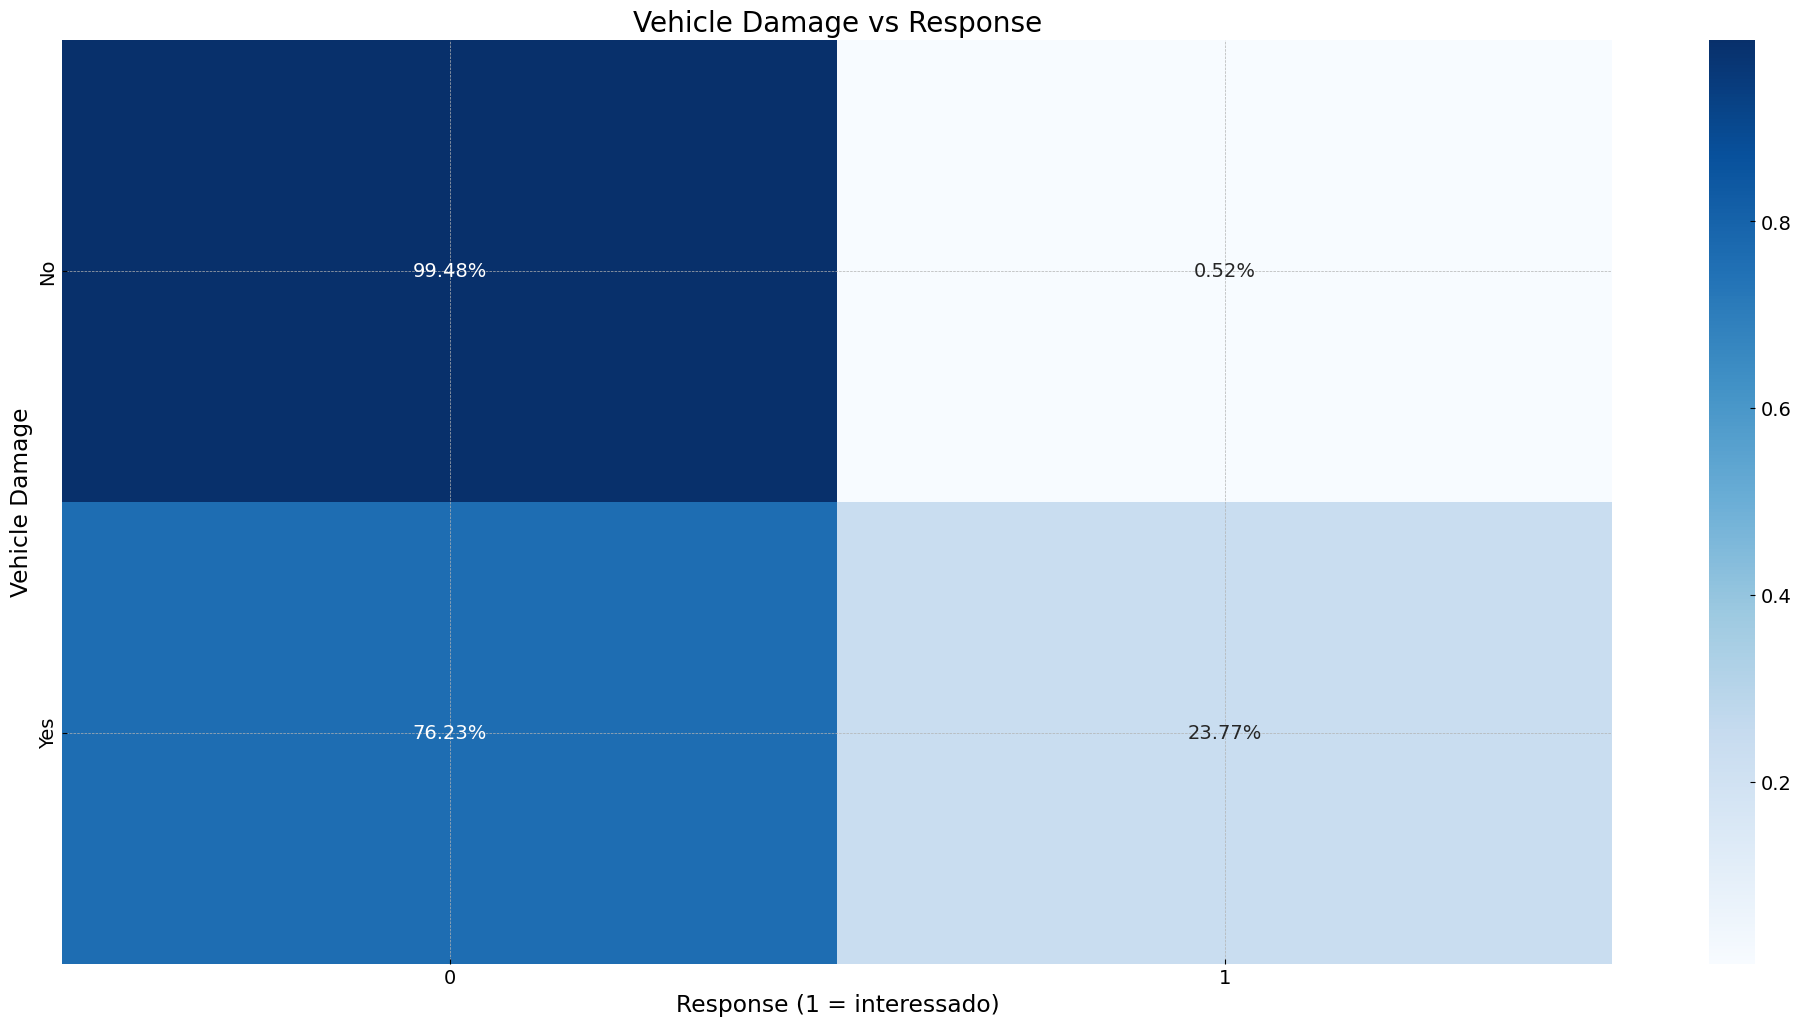

In [32]:
# vehicle_damage

# Tabela cruzada
crosstab_prop = pd.crosstab(
    df4['vehicle_damage'], 
    df4['response'], 
    normalize='index'
)

# Heatmap 
sns.heatmap(
    crosstab_prop,
    annot=True,
    fmt='.2%',
    cmap='Blues',
    cbar=True
)

plt.title('Vehicle Damage vs Response')
plt.xlabel('Response (1 = interessado)')
plt.ylabel('Vehicle Damage')
plt.show()

/tmp/ipykernel_49521/3033814677.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count = df4.groupby(['age_group', 'response']).size().unstack(fill_value=0)


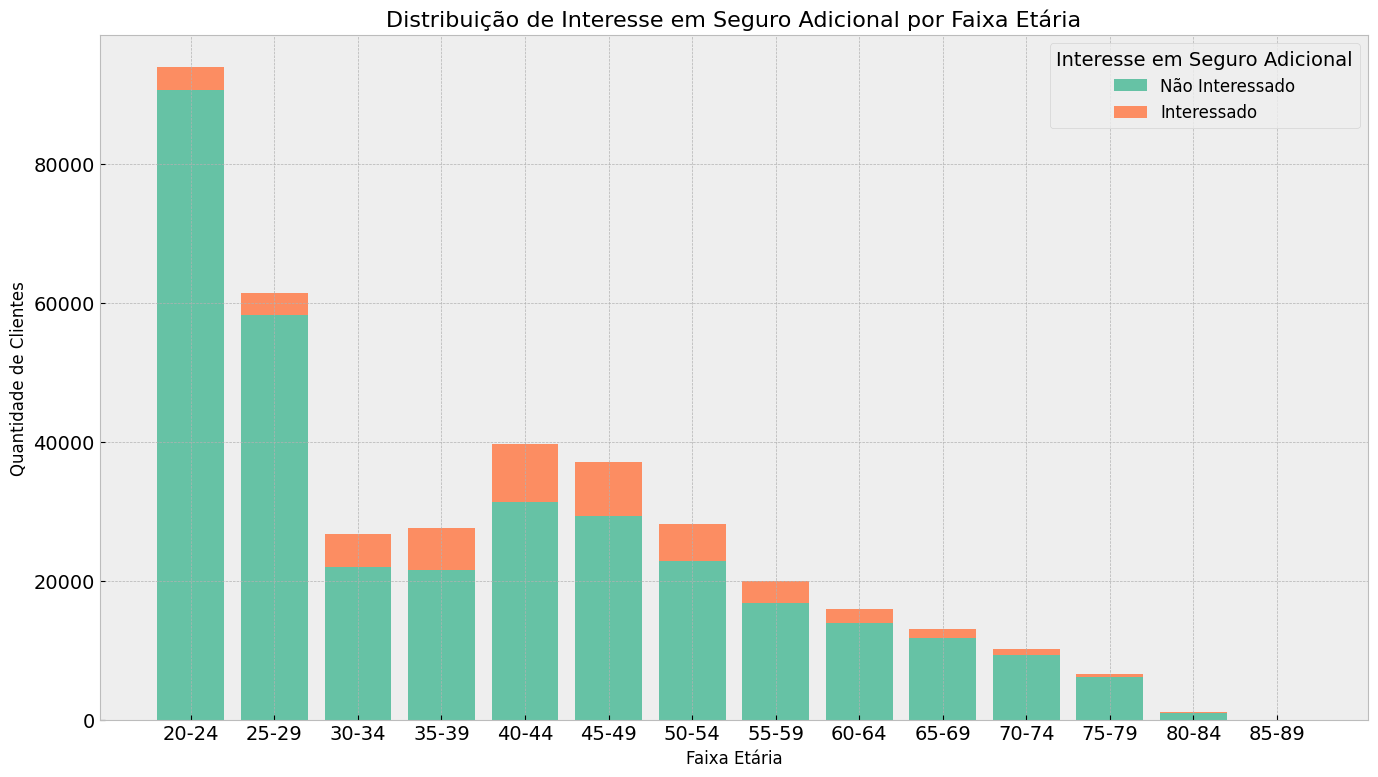

In [33]:
# Calcula a contagem de response = 0 e 1 por age_group
count = df4.groupby(['age_group', 'response']).size().unstack(fill_value=0)
count.columns = ['Não Interessado', 'Interessado']

count = count.sort_index()

fig, ax = plt.subplots(figsize=(14, 8))

bottom = None
for col in count.columns:
    ax.bar(count.index.astype(str), count[col], label=col, bottom=bottom)
    if bottom is None:
        bottom = count[col].values
    else:
        bottom += count[col].values

ax.set_title('Distribuição de Interesse em Seguro Adicional por Faixa Etária', fontsize=16)
ax.set_xlabel('Faixa Etária', fontsize=12)
ax.set_ylabel('Quantidade de Clientes', fontsize=12)
ax.legend(title='Interesse em Seguro Adicional', fontsize=12)

plt.tight_layout()
plt.show()

# 5 - DATA PREPARATION

In [81]:
X = df4.drop(columns=['response', 'age_group'])
y = df4['response'].copy()

x_train, x_val, y_train, y_val = train_test_split (X, y, test_size=0.20)

df5 = pd.concat([x_train, y_train], axis=1)

## 5.1 Stardalization

In [82]:
ss = StandardScaler()

# annual_premium
df5['annual_premium'] = ss.fit_transform(df5[['annual_premium']].values)

## 5.2 Rescaling

In [83]:
mms_age = MinMaxScaler()
mms_vintage = MinMaxScaler()

# age
df5['age'] = mms_age.fit_transform(df5[['age']].values)

# vintage
df5['vintage'] = mms_vintage.fit_transform(df5[['vintage']].values)

## 5.3 Escoding

In [84]:
te_region = TargetEncoder()
te_policy = TargetEncoder()
gender_dict = {'Male': 1, 'Female': 0}
damage_dict = {'Yes': 1, 'No': 0}


# 'gender' - Map simples ( 0 = female, 1 = male)
df5['gender'] = df5['gender'].map(gender_dict)

# 'vehicle_damage' - Map simples ( 0 = No, 1 = Yes)
df5['vehicle_damage'] = df5['vehicle_damage'].map(damage_dict)

# ----------------

# 'region_code'
df5['region_code'] = te_region.fit_transform(df5[['region_code']], df5['response'])

# 'policy_sales_channel'
df5['policy_sales_channel'] = te_policy.fit_transform(df5[['policy_sales_channel']], df5['response'])

# ----------------

# 'vehicle_age' - Ordinal Encoding
vehicle_dict = {'before_1_year': 1,
                'between_1_2_years': 2,
                'over_2_years': 3}
df5['vehicle_age'] = df5['vehicle_age'].map(vehicle_dict)

In [85]:
df5.head()

,id,gender,age,driving_license,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,response
41466,41467,0,0.030769,1,0.066763,1,1,0,-0.475109,0.029164,0.276817,0
8733,8734,1,0.353846,1,0.093281,0,2,1,0.546855,0.188440,0.031142,0
233738,233739,0,0.107692,1,0.185874,0,1,1,-1.623154,0.029164,0.183391,0
244251,244252,0,0.030769,1,0.081540,1,1,0,0.239643,0.029096,0.349481,0
90078,90079,0,0.153846,1,0.185874,0,2,1,0.163146,0.188440,0.117647,0


## 5.4 Validation Preparation

In [86]:
# =========================
# SCALERS 
# =========================

x_val.loc[:, 'annual_premium'] = ss.transform(
    x_val[['annual_premium']]
)

x_val.loc[:, 'age'] = mms_age.transform(
    x_val[['age']]
)

x_val.loc[:, 'vintage'] = mms_vintage.transform(
    x_val[['vintage']]
)

# =========================
# TARGET ENCODING
# =========================

x_val.loc[:, 'region_code'] = te_region.transform(
    x_val[['region_code']]
)

x_val.loc[:, 'policy_sales_channel'] = te_policy.transform(
    x_val[['policy_sales_channel']]
)

# =========================
# ORDINAL MANUAL
# =========================

x_val.loc[:, 'vehicle_age'] = x_val['vehicle_age'].map(
    vehicle_dict
)
x_val['gender'] = x_val['gender'].map(
    gender_dict
)
x_val['vehicle_damage'] = x_val['vehicle_damage'].map(
    damage_dict
)

/home/pollon/.pyenv/versions/3.10.13/envs/pa004_health_insurance/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/home/pollon/.pyenv/versions/3.10.13/envs/pa004_health_insurance/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/tmp/ipykernel_49521/974956748.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.04615385 0.35384615 0.49230769 ... 0.58461538 0.23076923 0.07692308]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_val.loc[:, 'age'] = mms_age.transform(
/home/pollon/.pyenv/versions/3.10.13/envs/pa004_health_insurance/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was

In [87]:
print('Number of Rows df5: {}'.format(df5.shape[0]))
print('Number of Cols df5: {}'.format(df5.shape[1]))

print('Number of Rows x_val: {}'.format(x_val.shape[0]))
print('Number of Cols x_val: {}'.format(x_val.shape[1]))

Number of Rows df5: 304887
Number of Cols df5: 12
Number of Rows x_val: 76222
Number of Cols x_val: 11


# 6 - FEATURE SELECTION

## 6.1 Boruta

In [88]:
X_train = df5.drop(columns=['response', 'id'])
y_train = df5['response'].copy()

In [ ]:
rf = RandomForestClassifier(
    n_estimators=1000,
    max_depth=None,
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
    class_weight='balanced_subsample'
)

boruta = BorutaPy(
    estimator=rf,
    n_estimators='auto',
    verbose=2,
    random_state=42
)

boruta.fit(
    X_train.values,
    y_train.values
)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	12
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	3
Tentative: 	2
Rejected: 	7
Iteration: 	9 / 100
Confirmed: 	3
Tentative: 	2
Rejected: 	7
Iteration: 	10 / 100
Confirmed: 	3
Tentative: 	2
Rejected: 	7
Iteration: 	11 / 100
Confirmed: 	3
Tentative: 	2
Rejected: 	7
Iteration: 	12 / 100
Confirmed: 	3
Tentative: 	2
Rejected: 	7
Iteration: 	13 / 100
Confirmed: 	3
Tentative: 	2
Rejected: 	7
Iteration: 	14 / 100
Confirmed: 	3
Tentative: 	2
Rejected: 	7
Iteration: 	15 / 100
Confirmed: 	3
Tentative: 	2
Rejected: 	7
Iteration: 	16 / 100
Confirmed: 	3
Tentative: 	2
Rejected: 	7
Iteration:

,estimator,RandomForestC...x7E05325F7D40)
,n_estimators,'auto'
,perc,100
,alpha,0.05
,two_step,True
,max_iter,100
,random_state,RandomState(M...0x7E05325F7D40
,verbose,2
,early_stopping,False
,n_iter_no_change,20
,n_estimators,28


In [48]:
selected_features = ['previously_insured', 'vehicle_damage', 'policy_sales_channel']
selected_features

['previously_insured', 'vehicle_damage', 'policy_sales_channel']

## 6.2 Feature Importance

In [79]:
rf_importance = RandomForestClassifier(
    n_estimators=1000,
    max_depth=None,
    min_samples_leaf=1,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
    class_weight='balanced_subsample'
)


rf_importance.fit(X_train, y_train)

,n_estimators,1000
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Feature ranking:
                feature  importance       std
0        vehicle_damage    0.178238  0.134779
1               vintage    0.151156  0.003322
2    previously_insured    0.146934  0.127096
3  policy_sales_channel    0.135866  0.060259
4        annual_premium    0.132720  0.002964
5           region_code    0.113759  0.006744
6                   age    0.107725  0.032131
7           vehicle_age    0.023161  0.036841
8                gender    0.009785  0.002557
9       driving_license    0.000656  0.000115


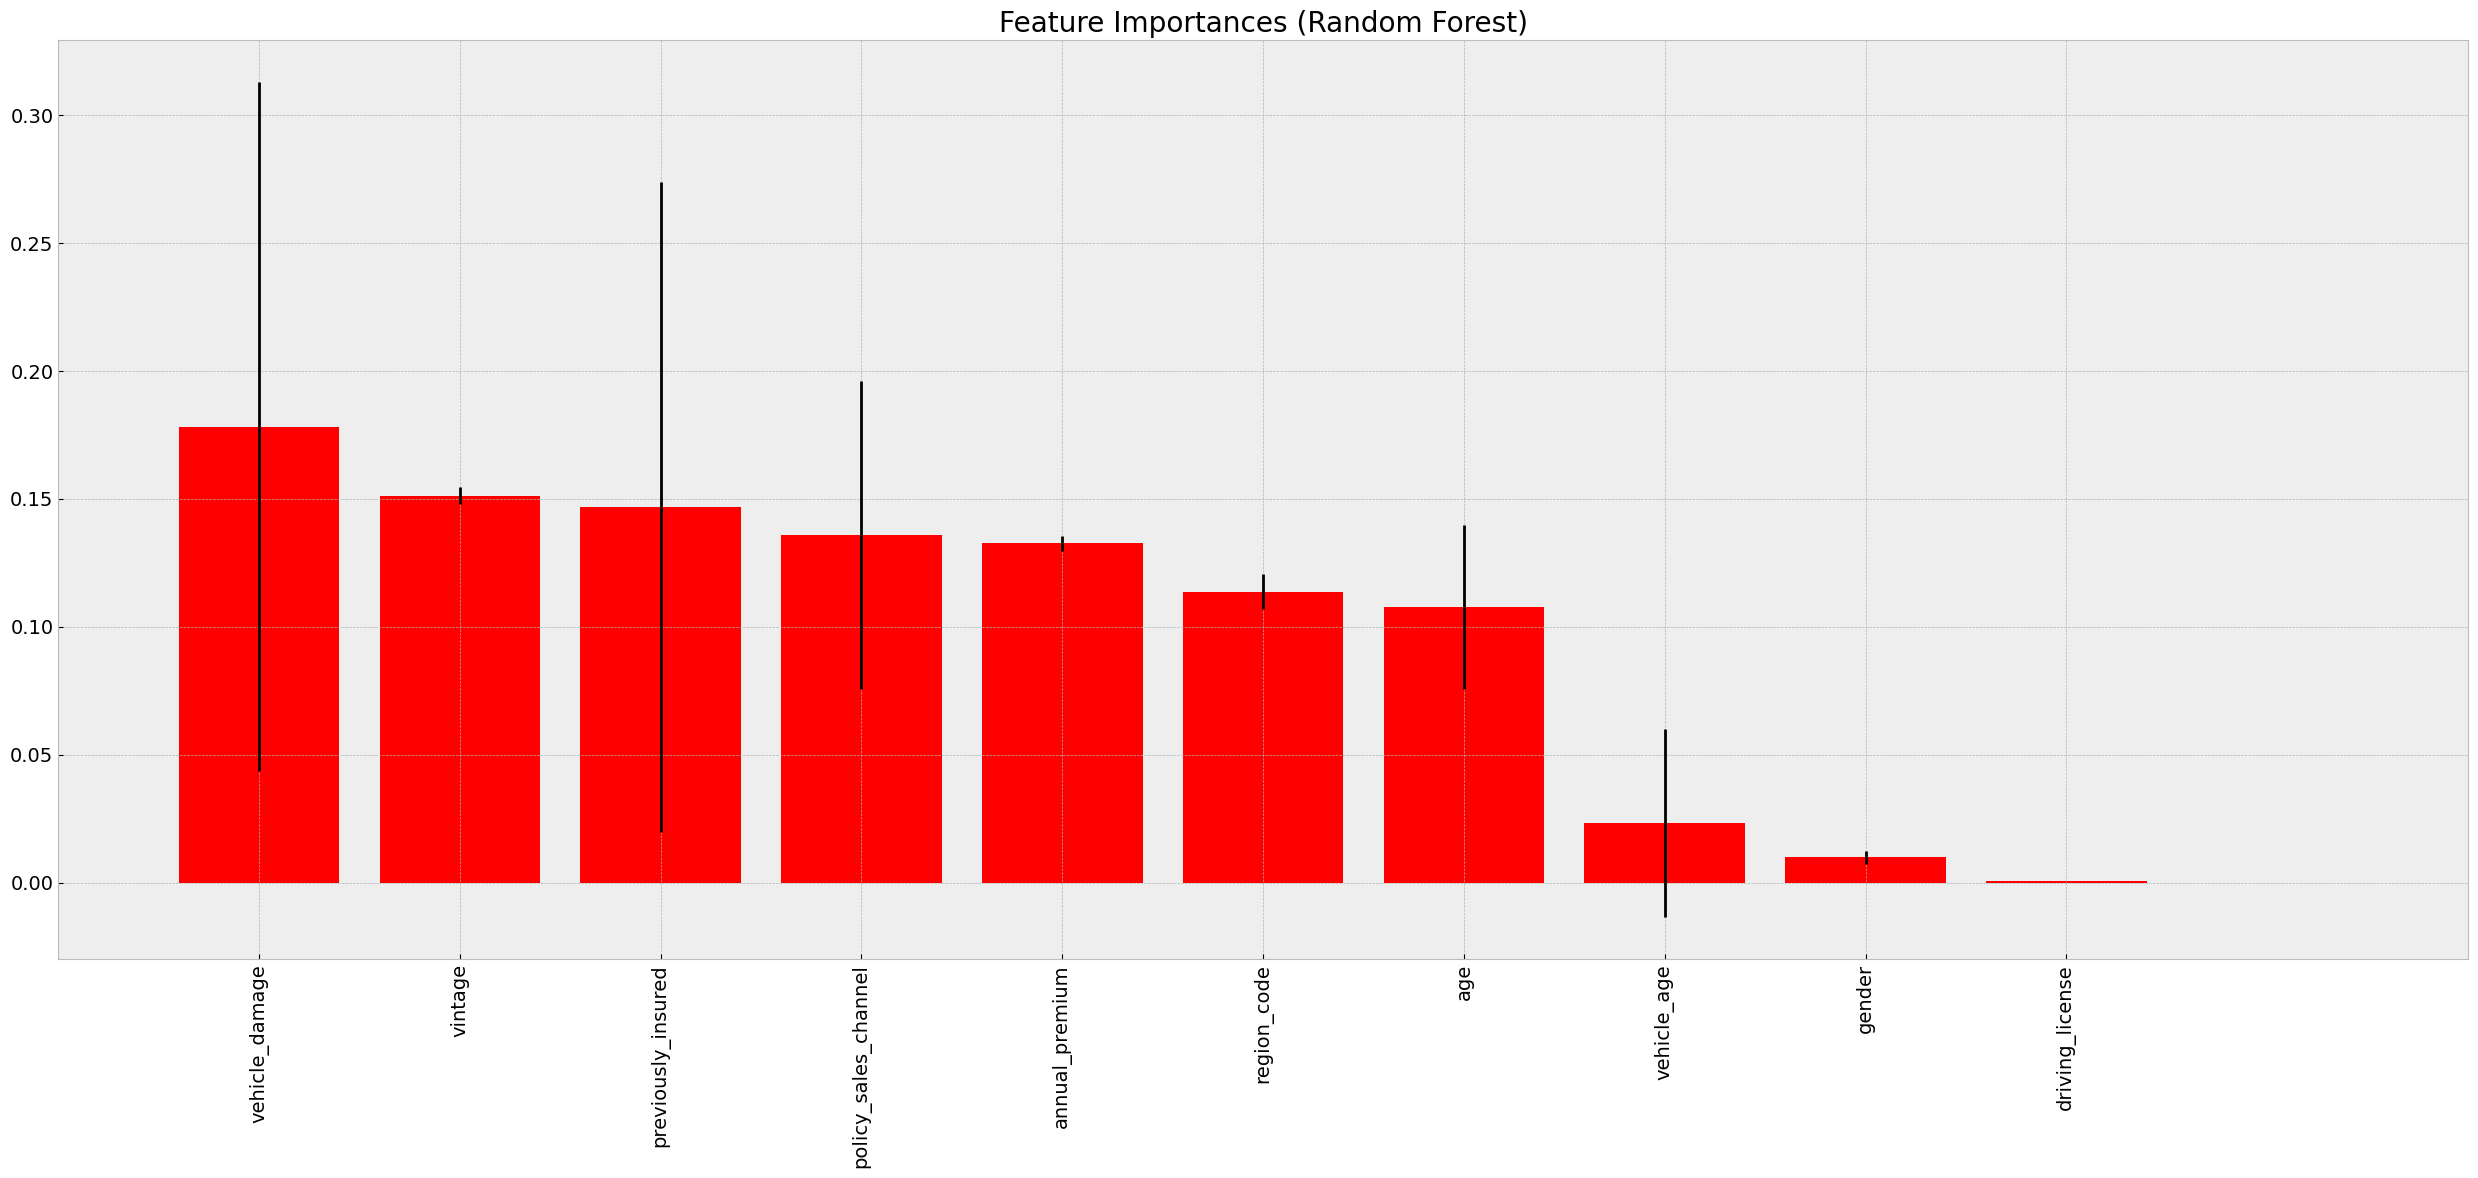

In [106]:
importances = np.mean(
    [tree.feature_importances_ for tree in rf_importance.estimators_], 
    axis=0
)
std = np.std(
    [tree.feature_importances_ for tree in rf_importance.estimators_], 
    axis=0
)

# Índices ordenados (do maior pro menor)
indices = np.argsort(importances)[::-1]

# Cria DataFrame com ranking
feature_ranking = pd.DataFrame({
    'feature': X_train.columns if hasattr(X_train, 'columns') else [f'feature_{i}' for i in range(X_train.shape[1])],
    'importance': importances,
    'std': std
})

# Ordena do maior pro menor
feature_ranking = feature_ranking.sort_values('importance', ascending=False).reset_index(drop=True)

print("Feature ranking:")
print(feature_ranking)

# Plot das importâncias
plt.title("Feature Importances (Random Forest)")
plt.bar(
    range(X_train.shape[1]), 
    importances[indices],
    color="r",
    yerr=std[indices],
    align="center"
)
plt.xticks(
    range(X_train.shape[1]), 
    [feature_ranking['feature'].iloc[i] for i in range(len(indices))],
    rotation=90
)
plt.xlim([-1, x_train.shape[1]])
plt.tight_layout()
plt.show()

In [105]:
feature_importance = ['vehicle_damage',
 'vintage',
 'previously_insured',
 'policy_sales_channel',
 'annual_premium',
 'region_code',
 'age']
feature_importance


['vehicle_damage',
 'vintage',
 'previously_insured',
 'policy_sales_channel',
 'annual_premium',
 'region_code',
 'age']

# 7 - MACHINE LEARNING

# 8 - FINE TUNNING